# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

import regex as re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

from wordcloud import WordCloud

c:\Coding\VsCode\pertalite-sentiment-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('dataset_tiktok-comments-scraper_2025-11-17_12-14-29-915.csv')
df.head()

,text,diggCount,replyCommentTotal,createTimeISO,uniqueId,videoWebUrl,uid,cid,avatarThumbnail
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,977,2025-10-09T03:10:07.000Z,ikmalbhrlm,https://www.tiktok.com/@dj_donny/video/7559032...,6962567982649541633,7559053960901559058,https://p19-common-sign.tiktokcdn-us.com/tos-a...
1,buku panduan,49090,185,2025-10-09T05:09:12.000Z,bang.kholis96,https://www.tiktok.com/@dj_donny/video/7559032...,7384053991606486022,7559084636891480853,https://p16-common-sign.tiktokcdn-us.com/tos-a...
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,105,2025-10-09T05:47:57.000Z,user4444_119,https://www.tiktok.com/@dj_donny/video/7559032...,6962785913933235202,7559094616738661121,https://p16-common-sign.tiktokcdn-us.com/tos-a...
3,kok mirip ya😹,14029,134,2025-10-09T05:04:40.000Z,symfahri3,https://www.tiktok.com/@dj_donny/video/7559032...,6632464555773607937,7559083478210904849,https://p16-common-sign.tiktokcdn-us.com/tos-a...
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,60,2025-10-09T02:23:03.000Z,whyfirmann,https://www.tiktok.com/@dj_donny/video/7559032...,6991736734669325314,7559041842743132936,https://p16-common-sign.tiktokcdn-us.com/tos-a...


In [3]:
df.drop(columns=['uniqueId','videoWebUrl','uid','cid','avatarThumbnail','replyCommentTotal'],inplace=True)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1942 non-null   object
 1   diggCount      2000 non-null   int64 
 2   createTimeISO  2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB


In [6]:
df.dropna(inplace=True)

In [7]:
df.head()

,text,diggCount,createTimeISO
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09T03:10:07.000Z
1,buku panduan,49090,2025-10-09T05:09:12.000Z
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09T05:47:57.000Z
3,kok mirip ya😹,14029,2025-10-09T05:04:40.000Z
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09T02:23:03.000Z


In [8]:
df['createTimeISO'] = pd.to_datetime(df['createTimeISO'])
df.head()

,text,diggCount,createTimeISO
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09 03:10:07+00:00
1,buku panduan,49090,2025-10-09 05:09:12+00:00
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09 05:47:57+00:00
3,kok mirip ya😹,14029,2025-10-09 05:04:40+00:00
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09 02:23:03+00:00


In [9]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F700-\U0001F77F"  # alchemical
    "\U0001F780-\U0001F7FF"  # geometric extended
    "\U0001F800-\U0001F8FF"  # supplemental arrows
    "\U0001F900-\U0001F9FF"  # supplemental symbols + pictographs
    "\U0001FA00-\U0001FA6F"  # chess, symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "\U00002700-\U000027BF"  # dingbats
    "\U00002600-\U000026FF"  # misc symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

# Scan your DataFrame column
# 1. Collect emojis per row WITHOUT adding a new DataFrame column
emoji_pattern = re.compile(r"\X", flags=re.UNICODE)

# Function to extract only emojis (single grapheme clusters)
def extract_emojis(text):
    chars = emoji_pattern.findall(text)
    return [c for c in chars if any(ord(x) > 1000 for x in c)]  # filters out non-emoji

# If the notebook or previous run created `df['emojis']`, drop it now to avoid keeping it
if 'emojis' in df.columns:
    df.drop(columns=['emojis'], inplace=True)

# Use a local Series to avoid adding a new column
emojis_per_row = df['text'].astype(str).apply(extract_emojis)

# 2. Count emoji presence per row (unique per row)
emoji_row_counts = {}

for emoji_list_row in emojis_per_row:
    unique_in_row = set(emoji_list_row)
    for e in unique_in_row:
        emoji_row_counts[e] = emoji_row_counts.get(e, 0) + 1

# 3. Build stats DataFrame
emoji_stats = pd.DataFrame([
    {
        "emoji": e,
        "rows_with_emoji": count,
        "percentage_of_rows": round((count / len(df)) * 100, 4),
    }
    for e, count in emoji_row_counts.items()
])

emoji_stats = emoji_stats.sort_values("rows_with_emoji", ascending=False)

# Keep only frequently observed emojis (more than 5 rows), without writing them to df
emoji_stats = emoji_stats[emoji_stats['rows_with_emoji'] > 5].reset_index(drop=True)
emoji_list = list(emoji_stats['emoji'])

# Print summary for quick inspection
emoji_list

['🤣',
 '🗿',
 '😂',
 '😭',
 '😁',
 '😹',
 '😏',
 '🔥',
 '🙏',
 '✅',
 '👍',
 '😅',
 '🤭',
 '🥰',
 '❌',
 '😡',
 '😌',
 '🥺',
 '❎',
 '😆']

In [10]:
# RoBERTa Sentiment Analysis Functions

# Load RoBERTa model (using a public alternative)
tokenizer = AutoTokenizer.from_pretrained("w11wo/indonesian-roberta-base-sentiment-classifier")
model = AutoModelForSequenceClassification.from_pretrained("w11wo/indonesian-roberta-base-sentiment-classifier")
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Expanded slang dictionary for better normalization of informal Indonesian text
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "nggak": "tidak",
    "ngak": "tidak",
    "tdk": "tidak",

    "bgt": "banget",

    "bener": "benar",
    "bnr": "benar",

    "bkn": "bukan",

    "bgus": "bagus",
    "bagus": "bagus",
    "keren": "bagus",
    "mantap": "bagus",

    "mantul": "mantap",
    "mantapjiwa": "mantap",

    "jelek": "jelek",

    "asik": "asyik",
    "asyik": "asyik",

    "oke": "baik",
    "ok": "baik",
    "okey": "baik",

    "iya": "ya",
    "ya": "ya",
    "yah": "ya",
    "sih": "ya",

    "syg": "sayang",
    "sayang": "sayang",

    "kk": "kakak",
    "kak": "kakak",
    "mbak": "kakak",
    "mas": "kakak",
    "abang": "abang",

    "sis": "saudara perempuan",
    "bro": "teman",
    "temen": "teman",
    "teman": "teman",

    "gue": "saya",
    "gw": "saya",
    "aku": "saya",

    "lu": "kamu",
    "lo": "kamu",
    "kamu": "kamu",
    "kmu": "kamu",

    "kalo": "kalau",
    "klo": "kalau",
    "kalau": "kalau",

    "gmn": "gimana",
    "gmna": "gimana",
    "gimana": "gimana",

    "dgn": "dengan",
    "dr": "dari",
    "yg": "yang",
    "sbg": "sebagai",

    "saja": "saja",

    "udh": "sudah",
    "udah": "sudah",
    "sdh": "sudah",

    "blm": "belum",
    "belom": "belum",

    "pls": "tolong",
    "tolong": "tolong",

    "makasih": "terima kasih",
    "mks": "terima kasih",
    "makaci": "terima kasih",
    "makasihh": "terima kasih",
    "thanks": "terima kasih",
    "thx": "terima kasih",
    "ty": "terima kasih",

    "kmrn": "kemarin",
    "skrg": "sekarang",
    "bsk": "besok",
    "ntr": "nanti",

    "jgn": "jangan",
    "jgnlah": "jangan",

    "cm": "cuma",
    "cuma": "cuma",
    "cuman": "cuma",

    "bentar": "sebentar",
    "bntr": "sebentar",
    "brb": "sebentar",

    "tpi": "tapi",
    "tp": "tapi",

    "krn": "karena",

    "bales": "balas",
    "balesin": "balas",

    "mnrt": "menurut",

    "sr": "sore",

    "yaudahlah": "ya sudah",

    "omg": "waduh",
    "gws": "semoga cepat sembuh",

    "gg": "good game",

    "btw": "ngomong-ngomong",
    "sm": "sama",
    "smn": "samaan",
    "trus": "terus",
    "trs": "terus",
    "lg": "lagi",
    "lgi": "lagi",
    "pdhl": "padahal",
    "pd": "pada",
    "td": "tadi",
    "tadi2": "tadi",
    "ngap": "mengapa",
    "knp": "kenapa",
    "kenapa": "kenapa",
    "bbrp": "beberapa",
    "ttp": "tetap",

    "wkwk": "tertawa",
    "wkwkwk": "tertawa",
    "haha": "tertawa",
    "hehe": "tertawa",
    "lol": "tertawa",
    "rofl": "tertawa",

    "nt": "nice try",
    "ez": "mudah",
    "idk": "saya tidak tahu",
    "imo": "menurut saya",
    "imho": "menurut saya",
    "cmiiw": "koreksi kalau saya salah",
    "otw": "sedang dalam perjalanan",
    "oot": "di luar topik",
    "asl": "umur jenis kelamin lokasi",
    "jk": "cuma bercanda",

    "anj": "anjing",
    "anjay": "anjing",
    "anjir": "anjing",
    "anjrit": "anjing",
    "anjass": "anjing",

    "baper": "bawa perasaan",
    "kepo": "ingin tahu",
    "mager": "malas gerak",
    "woles": "santai",
    "alay": "norak",
    "php": "pemberi harapan palsu",
    "fomo": "takut ketinggalan",
    "flexing": "pamer",
    "ghosting": "menghilang tanpa kabar",
    "hbd": "selamat ulang tahun",
    "yolo": "hidup cuma sekali",

    "gan": "teman",
    "agan": "teman",
    "mimin": "admin",
    "cupu": "kurang mahir",
    "pdkt": "pendekatan",

    "noob": "pemula",
    "newbie": "pemula",
    "mabar": "main bareng",
    "bot": "pemain buruk",
    "wibu": "penggemar budaya jepang",
    "camp": "bertahan di satu tempat",
    "rush": "serangan cepat",

    "bae": "kesayangan",
    "bucin": "budak cinta",
    "gokil": "gila keren",
    "hf": "bersenang-senang",
    "gl": "semoga berhasil",

    "ig": "instagram"
}


def clean_text(text):
    if pd.isna(text) or text.strip() == "":
        return ""
    text = text.lower()
    # Normalize repeated characters (e.g., "bangetttt" -> "banget") using proper backreferences
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # Preserve emojis as they are critical sentiment signals in informal text like TikTok comments
    # Include emojis from emoji_list (those appearing in >5 rows)
    allowed_emojis = ''.join(emoji_list) if 'emoji_list' in globals() else ""
    allowed_chars = r"\w\s.!?#" + allowed_emojis
    text = re.sub(r"[^" + allowed_chars + r"]", " ", text)
    return text.strip()

def normalize_slang(text, slang_dict):
    if not text:
        return ""
    return " ".join([slang_dict.get(w, w) for w in text.split()])

def predict_roberta(text):
    if not text.strip():
        return "neutral", 0.0
    result = sentiment_pipeline(text)[0]
    return result["label"], float(result["score"])

Device set to use cpu


In [11]:
# Apply RoBERTa preprocessing and prediction
df['cleaned_text'] = df['text'].apply(clean_text)
df['normalized_text'] = df['cleaned_text'].apply(lambda x: normalize_slang(x, slang_dict))

# Predict sentiment using RoBERTa on normalized text (no stemming needed for transformer models with subword tokenization)
df['roberta_label'], df['roberta_score'] = zip(*df['normalized_text'].apply(predict_roberta))

# Categorize RoBERTa sentiment (binary: only positive or negative)
def categorize_roberta(label):
    if 'positive' in label.lower() or 'LABEL_1' in label:
        return 'positive'
    elif 'negative' in label.lower() or 'LABEL_0' in label:
        return 'negative'
    else:
        # Map neutral to positive (you can change to 'negative' if preferred)
        return 'negative'

df['roberta_sentiment'] = df['roberta_label'].apply(categorize_roberta)

In [12]:
df.head()

,text,diggCount,createTimeISO,cleaned_text,normalized_text,roberta_label,roberta_score,roberta_sentiment
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09 03:10:07+00:00,setiap bahlil ngomong kiamat maju 1jam,setiap bahlil ngomong kiamat maju 1jam,neutral,0.976646,negative
1,buku panduan,49090,2025-10-09 05:09:12+00:00,buku panduan,buku panduan,positive,0.551686,positive
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09 05:47:57+00:00,kayaknya si bahlil terinspirasi dari karakter ...,kayaknya si bahlil terinspirasi dari karakter ...,positive,0.997089,positive
3,kok mirip ya😹,14029,2025-10-09 05:04:40+00:00,kok mirip ya😹,kok mirip ya😹,negative,0.817127,negative
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09 02:23:03+00:00,campuran etanol 10 . korupsinya berapa persen? 🤣,campuran etanol 10 . korupsinya berapa persen? 🤣,negative,0.999304,negative


In [13]:
df[df['roberta_score'] <=.65].sort_values(by='roberta_score', ascending=False).head(25)

,text,diggCount,createTimeISO,cleaned_text,normalized_text,roberta_label,roberta_score,roberta_sentiment
1129,mentrinya dari jaman jokowhy,0,2025-11-06 00:07:13+00:00,mentrinya dari jaman jokowhy,mentrinya dari jaman jokowhy,neutral,0.649124,negative
1850,ramah lingkungan tapi tidak rama sama mesin ke...,1,2025-10-14 02:14:01+00:00,ramah lingkungan tapi tidak rama sama mesin ke...,ramah lingkungan tapi tidak rama sama mesin ke...,negative,0.645921,negative
307,"mewakilkan masyarakat sekali lu bang , menyala 🔥",2,2025-10-15 13:02:25+00:00,mewakilkan masyarakat sekali lu bang menyala 🔥,mewakilkan masyarakat sekali kamu bang menyala 🔥,negative,0.645921,negative
1210,coba aja motor BAPAK BAHLIL di isi pertalite j...,0,2025-11-01 12:27:45+00:00,coba aja motor bapak bahlil di isi pertalite j...,coba aja motor bapak bahlil di isi pertalite j...,negative,0.645459,negative
500,kita campur bayar bensin duitnya 10% daun keri...,3,2025-10-09 23:15:17+00:00,kita campur bayar bensin duitnya 10 daun keri...,kita campur bayar bensin duitnya 10 daun kerin...,negative,0.644342,negative
805,ni orang cocok jadi presiden Bangladesh,2,2025-10-09 09:36:18+00:00,ni orang cocok jadi presiden bangladesh,ni orang cocok jadi presiden bangladesh,positive,0.642379,positive
1729,di luar udah sedikit yang pake 2 tak lil bahli...,1,2025-10-14 12:39:40+00:00,di luar udah sedikit yang pake 2 tak lil bahli...,di luar sudah sedikit yang pake 2 tak lil bahl...,negative,0.640358,negative
66,maaf lepas🙏🙏🙏,1853,2025-10-13 09:28:21+00:00,maaf lepas🙏🙏,maaf lepas🙏🙏,negative,0.640173,negative
1994,gua pindah aja bang ke malaysia😄😄,1,2025-10-12 08:43:46+00:00,gua pindah aja bang ke malaysia,gua pindah aja bang ke malaysia,neutral,0.638988,negative
372,bahlil : intinya rakyat harus tetap sengsara,4,2025-10-09 03:30:26+00:00,bahlil intinya rakyat harus tetap sengsara,bahlil intinya rakyat harus tetap sengsara,negative,0.638181,negative


In [14]:
df = df[df['roberta_score'] >.65]

In [15]:
df_negative = df[df['roberta_sentiment'] == 'negative']
df_positive = df[df['roberta_sentiment'] == 'positive']

In [16]:
df_positive['normalized_text'].head(25)

2      kayaknya si bahlil terinspirasi dari karakter ...
22                                          untuk bersih
39                                  bahlil bahlul 😂🤣😂🤣😂🤣
45        dukun bahlil kuat benar dah kaga diganti ganti
58     terima kasih bang sudah bantu speak up manusia...
68     bahlil itu belajar nya drimna kok dibilang bgus👍😁
90                                  ❌️bahlil. ✅️bahlul🗿🗿
96                                    bahlil artinya apa
106    tampang kayak gitu kok bisa jadi menteri.terus...
123    saya lebih percaya statement bang fitra eri da...
145    maksud mr bahlil agar kendaraan motor cepat ru...
146                         saking pinternya ke blinger😏
150                                bang semangat terus 🤣
159              kalok bagus.knpa spbu suasta ttup lill.
160                 kalau bagus tidak perlu paksa2 deh..
162                                           si bahlil🗿
172                          bahlil muka nya lucu imut2😅
178      gua kangen nungguin ka

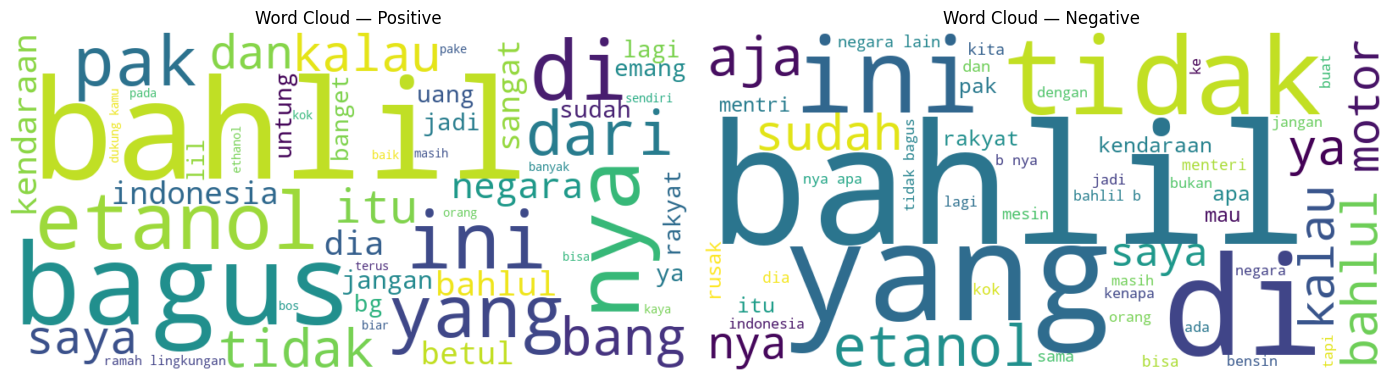

In [17]:
# Word Cloud for Positive and Negative Comments (side-by-side)
# Use `normalized_text` if available, otherwise fall back to `text`
text_col = 'normalized_text' if 'normalized_text' in df.columns else 'text'
# Build the text blobs safely (ensure strings)
negative_text = ' '.join(df_negative[text_col].astype(str)) if not df_negative.empty else ''
positive_text = ' '.join(df_positive[text_col].astype(str)) if not df_positive.empty else ''
# Provide a safe non-empty string to WordCloud.generate() if needed
neg_blob = negative_text if negative_text.strip() else ' '
pos_blob = positive_text if positive_text.strip() else ' '
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(neg_blob)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(pos_blob)

plt.figure(figsize=(14, 6))
# Positive on the left
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Positive')
# Negative on the right
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Negative')
plt.tight_layout()
plt.show()

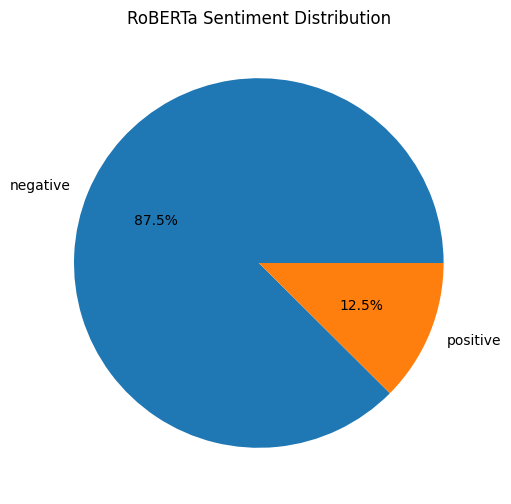

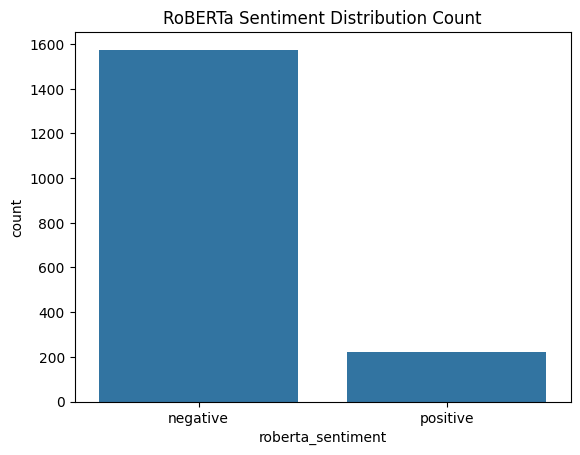

In [18]:
# Additional RoBERTa Visualizations

# Pie chart for RoBERTa labels
df['roberta_sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('RoBERTa Sentiment Distribution')
plt.ylabel('')
plt.show()

sns.countplot(x=df['roberta_sentiment'])
plt.title('RoBERTa Sentiment Distribution Count')
plt.show()

# Sum diggCount per sentiment and show a bar chart

In [19]:
# Ensure diggCount is numeric
df['diggCount'] = pd.to_numeric(df['diggCount'], errors='coerce').fillna(0).astype(int)

sent_col = df['roberta_sentiment']
sums = df.groupby(sent_col)['diggCount'].sum().reset_index().rename(columns={'diggCount':'total_digg'})

# Sort to show highest first
sums = sums.sort_values('total_digg', ascending=False)
print('Total diggCount per sentiment:')
print(sums.to_string(index=False))

Total diggCount per sentiment:
roberta_sentiment  total_digg
         negative      200450
         positive       17957


In [20]:
sums

,roberta_sentiment,total_digg
0,negative,200450
1,positive,17957


In [21]:
df.sort_values('diggCount', ascending=False).head(25)

,text,diggCount,createTimeISO,cleaned_text,normalized_text,roberta_label,roberta_score,roberta_sentiment
0,"setiap bahlil ngomong, kiamat maju 1jam",87436,2025-10-09 03:10:07+00:00,setiap bahlil ngomong kiamat maju 1jam,setiap bahlil ngomong kiamat maju 1jam,neutral,0.976646,negative
4,campuran etanol 10%. korupsinya berapa persen? 🤣,30811,2025-10-09 02:23:03+00:00,campuran etanol 10 . korupsinya berapa persen? 🤣,campuran etanol 10 . korupsinya berapa persen? 🤣,negative,0.999304,negative
2,kayaknya si bahlil terinspirasi dari karakter ...,17011,2025-10-09 05:47:57+00:00,kayaknya si bahlil terinspirasi dari karakter ...,kayaknya si bahlil terinspirasi dari karakter ...,positive,0.997089,positive
126,tiap bahlil ngomong kiamat maju 1 jam,15524,2025-10-10 09:43:39+00:00,tiap bahlil ngomong kiamat maju 1 jam,tiap bahlil ngomong kiamat maju 1 jam,negative,0.709954,negative
3,kok mirip ya😹,14029,2025-10-09 05:04:40+00:00,kok mirip ya😹,kok mirip ya😹,negative,0.817127,negative
99,PAK PRABOWO TOLONG GANTI BAHLIL😩 apalah ini pe...,8872,2025-10-09 03:58:03+00:00,pak prabowo tolong ganti bahlil apalah ini pe...,pak prabowo tolong ganti bahlil apalah ini per...,neutral,0.998480,negative
5,bayar pajaknya boleh campur pake daun singkong?,5802,2025-10-09 05:32:20+00:00,bayar pajaknya boleh campur pake daun singkong?,bayar pajaknya boleh campur pake daun singkong?,neutral,0.992048,negative
130,pecat menti satu ini.. muak liatnya..,5493,2025-10-10 04:40:35+00:00,pecat menti satu ini.. muak liatnya..,pecat menti satu ini.. muak liatnya..,negative,0.999465,negative
128,buktinya Shell dan Vivo gak mau beli.,5368,2025-10-10 04:08:48+00:00,buktinya shell dan vivo gak mau beli.,buktinya shell dan vivo tidak mau beli.,negative,0.998675,negative
10,ko bisa jadi menteri,4464,2025-10-09 01:58:17+00:00,ko bisa jadi menteri,ko bisa jadi menteri,neutral,0.993598,negative


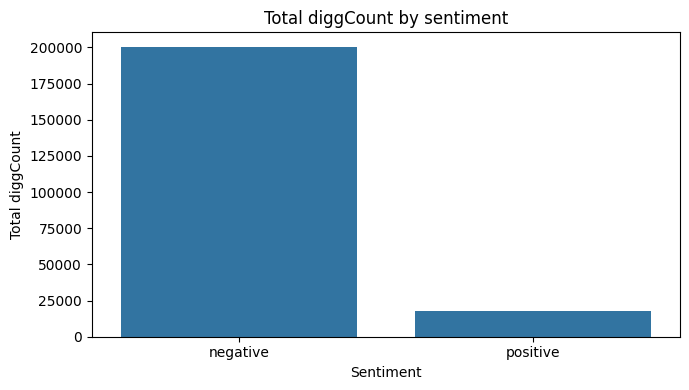

In [22]:
# Plotting
plt.figure(figsize=(7,4))
sns.barplot(x=sums['roberta_sentiment'], y=sums['total_digg'])
plt.title('Total diggCount by sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Total diggCount')
plt.tight_layout()
plt.show()

In [23]:
label_maps = {
    'positive':1,
    'negative':0
}

df['roberta_label'] = df['roberta_label'].map(label_maps)
df['roberta_sentiment'] = df['roberta_sentiment'].map(label_maps)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1799 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   text               1799 non-null   object             
 1   diggCount          1799 non-null   int64              
 2   createTimeISO      1799 non-null   datetime64[ns, UTC]
 3   cleaned_text       1799 non-null   object             
 4   normalized_text    1799 non-null   object             
 5   roberta_label      1408 non-null   float64            
 6   roberta_score      1799 non-null   float64            
 7   roberta_sentiment  1799 non-null   int64              
dtypes: datetime64[ns, UTC](1), float64(2), int64(2), object(3)
memory usage: 126.5+ KB


In [25]:
df_ready =  df.drop(columns=['roberta_score','roberta_label'])

## Stratified split, Random Forest training and evaluation
We will perform a stratified split on `df_ready` using `indobert_label` as the label, with a 70/15/15 train/val/test ratio. After that we use TF-IDF features and train a `RandomForestClassifier` and evaluate on validation and test sets.

In [26]:
# df_ready must contain the text column (normalized_text is preferred) and the label `roberta_label`
text_col = 'normalized_text' if 'normalized_text' in df_ready.columns else ('cleaned_text' if 'cleaned_text' in df_ready.columns else 'text')
label_col = 'roberta_label' if 'roberta_label' in df_ready.columns else ('roberta_sentiment' if 'roberta_sentiment' in df_ready.columns else None)
assert label_col is not None, 'No label column found in df_ready; expected roberta_label or roberta_sentiment'
X = df_ready[text_col].astype(str).values
y = df_ready[label_col].values

In [27]:
# First split: hold out test set (15%) stratified
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
# Second split: split the remaining 85% into train and val with val about 15% of original -> test_size = 0.15/0.85
val_fraction = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=val_fraction, stratify=y_train_val, random_state=42)
# Print sizes
print(f'Original: {len(X)} rows')
print(f'Train: {len(X_train)} ({len(X_train)/len(X):.2%})')
print(f'Validation: {len(X_val)} ({len(X_val)/len(X):.2%})')
print(f'Test: {len(X_test)} ({len(X_test)/len(X):.2%})')

Original: 1799 rows
Train: 1259 (69.98%)
Validation: 270 (15.01%)
Test: 270 (15.01%)


In [28]:
# Train RandomForest on training set and evaluate on validation set
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [29]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_val_pred = rf.predict(X_val_tfidf)
print('Validation set results:')
print(classification_report(y_val, y_val_pred))
print('Confusion matrix (validation):')
print(confusion_matrix(y_val, y_val_pred))
print('Validation accuracy:', accuracy_score(y_val, y_val_pred))

Validation set results:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       236
           1       0.38      0.32      0.35        34

    accuracy                           0.85       270
   macro avg       0.64      0.62      0.63       270
weighted avg       0.84      0.85      0.84       270

Confusion matrix (validation):
[[218  18]
 [ 23  11]]
Validation accuracy: 0.8481481481481481


In [30]:
# Retrain final model on train+val and evaluate on test set
# Fit new TF-IDF on combined train+val so it sees those features too
vectorizer_final = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_val_tfidf = vectorizer_final.fit_transform(X_train_val)
X_test_tfidf = vectorizer_final.transform(X_test)
rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_final.fit(X_train_val_tfidf, y_train_val)
y_test_pred = rf_final.predict(X_test_tfidf)

In [31]:
print('Test set results (final model trained on train+val):')
print(classification_report(y_test, y_test_pred))
print('Confusion matrix (test):')
print(confusion_matrix(y_test, y_test_pred))
print('Test accuracy:', accuracy_score(y_test, y_test_pred))

Test set results (final model trained on train+val):
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       236
           1       0.57      0.38      0.46        34

    accuracy                           0.89       270
   macro avg       0.74      0.67      0.70       270
weighted avg       0.87      0.89      0.88       270

Confusion matrix (test):
[[226  10]
 [ 21  13]]
Test accuracy: 0.8851851851851852


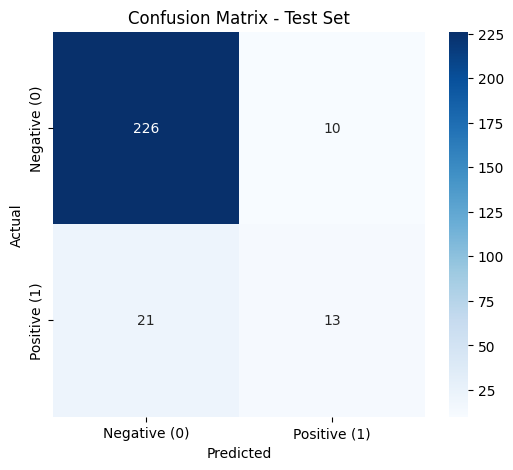

In [32]:
# Visualize the confusion matrix for the test set
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()